In [1]:
# pip install galpy

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import time as tm
from time import time
import fitsio
import pandas as pd
from galpy.potential import MWPotential2014, vcirc, evaluateRforces
from galpy.orbit import Orbit
from scipy.stats import gaussian_kde

In [3]:
paper_ready_catalog_1 = 'FINAL_PAPER-READY_CATALOGUE_MNRAS.fits'
paper_ready_catalog_2 = 'FINAL_PAPER-READY_CATALOGUE_MNRAS_KINEMATICS.fits'
def ensure_native_endian(df):
    """Convert all numeric columns in a DataFrame to native byte order."""
    for col in df.columns:
        dtype = df[col].dtype
        # skip non-numeric or already native columns
        if dtype.byteorder in ('=', '|'):
            continue
        if np.issubdtype(dtype, np.number):
            # NumPy 2.0-safe endian swap
            df[col] = df[col].astype(dtype.newbyteorder('='))
        else:
            # Strings/objects from FITS often come as bytes — decode safely
            try:
                df[col] = df[col].astype(str)
            except Exception:
                pass
    return df

In [ ]:
with fitsio.FITS(paper_ready_catalog_1) as hdul:
    data_full = hdul[1].read()
    print(hdul[1])

catofull = pd.DataFrame(data_full)
catofull = ensure_native_endian(catofull)


  file: FINAL_PAPER-READY_CATALOGUE_MNRAS.fits
  extension: 1
  type: BINARY_TBL
  extname: Joined
  rows: 357415
  column info:
    Gaia_dr3_id         i8  
    RA                  f8  
    e_RA                f8  
    DEC                 f8  
    e_DEC               f8  
    plx                 f8  
    e_plx               f8  
    rvs_snr             f8  
    flag_cannon         i2  
    Teff                f8  
    e_Teff              f8  
    logg                f8  
    e_logg              f8  
    vsini               f8  
    e_vsini             f8  
    FeH                 f8  
    e_FeH               f8  
    CaFe                f8  
    e_CaFe              f8  
    SiFe                f8  
    e_SiFe              f8  
    TiFe                f8  
    e_TiFe              f8  
    NiFe                f8  
    e_NiFe              f8  
    ZrFe                f8  
    e_ZrFe              f8  
    CeFe                f8  
    e_CeFe              f8  
    NdFe                f8  


In [5]:
catofull

,Gaia_dr3_id,RA,e_RA,DEC,e_DEC,plx,e_plx,rvs_snr,flag_cannon,Teff,...,CeFe,e_CeFe,NdFe,e_NdFe,flag_ZrFe,flag_CeFe,flag_NdFe,chi_sq,log_chi_sq,chi-sq/2401
0,4648162939452971008,82.972777,0.208680,-76.339716,0.238998,30.595578,0.218870,568.177900,0,4695.672785,...,-0.278740,0.019134,-0.127762,0.012092,1,1,0,780.392561,2.892313,0.325028
1,2669361142702790272,329.729096,0.114853,-4.374234,0.148962,26.752954,0.129162,614.188350,0,4920.053765,...,-0.099722,0.018022,0.044890,0.012738,0,1,0,1277.997973,3.106530,0.532277
2,3734970154071002624,191.595198,0.046338,9.537664,0.029664,22.876105,0.062961,1289.207500,0,4876.518059,...,-0.021269,0.018259,0.107527,0.012955,0,1,0,3417.988456,3.533771,1.423569
3,1486177813925663744,213.597982,0.011677,41.518289,0.014784,22.294481,0.018748,979.416700,0,4891.502578,...,-0.230951,0.015672,-0.173784,0.009184,1,1,0,2639.197946,3.421472,1.099208
4,4236276194243977344,302.008106,0.033708,-0.678486,0.020075,21.535668,0.040194,994.149400,0,4824.487964,...,-0.135560,0.018863,-0.010776,0.011696,0,1,0,1254.138234,3.098345,0.522340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357410,5634292240980562816,137.143961,0.019696,-31.802984,0.027984,0.004050,0.038738,30.590206,0,4783.998426,...,0.109372,0.122466,0.204530,0.117016,0,1,0,3734.784823,3.572266,1.555512
357411,5641217961646395392,132.522890,0.050591,-30.899384,0.074477,0.003185,0.101496,54.329600,0,4676.432873,...,-0.136316,0.260471,-0.037219,0.204196,1,0,1,2224.173110,3.347169,0.926353
357412,6663997387335164672,291.273268,0.011932,-45.139218,0.009612,0.002049,0.016293,20.502920,0,4241.192117,...,0.655373,0.172977,0.197039,0.153948,0,1,1,2821.367278,3.450460,1.175080
357413,5869961151043007872,202.941002,0.025337,-59.707619,0.033225,0.002008,0.046463,21.948862,1,3761.674234,...,-0.088701,0.159842,-0.037467,0.119043,1,1,0,3860.068116,3.586595,1.607692


In [6]:
with fitsio.FITS(paper_ready_catalog_2) as hdul:
    data_full = hdul[1].read()
    print(hdul[1])

dogofull = pd.DataFrame(data_full)
dogofull = ensure_native_endian(dogofull)


  file: FINAL_PAPER-READY_CATALOGUE_MNRAS_KINEMATICS.fits
  extension: 1
  type: BINARY_TBL
  extname: /Users/47491418/Desktop/FILES/MODEL-2/1on1_Total-error_GSE-match/MCM
  rows: 357415
  column info:
    source_id           i8  
    Lx                  f8  
    Ly                  f8  
    Lz                  f8  
    L_perp              f8  
    Energy              f8  
    sqrt_Jr             f8  
    eccentricity        f8  
    vR                  f8  
    vphi                f8  
    vz                  f8  
    vnet                f8  


In [7]:
# catofull["flag_cannon"]

flagged = catofull[catofull["flag_cannon"] == 0]

flagged

,Gaia_dr3_id,RA,e_RA,DEC,e_DEC,plx,e_plx,rvs_snr,flag_cannon,Teff,...,CeFe,e_CeFe,NdFe,e_NdFe,flag_ZrFe,flag_CeFe,flag_NdFe,chi_sq,log_chi_sq,chi-sq/2401
0,4648162939452971008,82.972777,0.208680,-76.339716,0.238998,30.595578,0.218870,568.177900,0,4695.672785,...,-0.278740,0.019134,-0.127762,0.012092,1,1,0,780.392561,2.892313,0.325028
1,2669361142702790272,329.729096,0.114853,-4.374234,0.148962,26.752954,0.129162,614.188350,0,4920.053765,...,-0.099722,0.018022,0.044890,0.012738,0,1,0,1277.997973,3.106530,0.532277
2,3734970154071002624,191.595198,0.046338,9.537664,0.029664,22.876105,0.062961,1289.207500,0,4876.518059,...,-0.021269,0.018259,0.107527,0.012955,0,1,0,3417.988456,3.533771,1.423569
3,1486177813925663744,213.597982,0.011677,41.518289,0.014784,22.294481,0.018748,979.416700,0,4891.502578,...,-0.230951,0.015672,-0.173784,0.009184,1,1,0,2639.197946,3.421472,1.099208
4,4236276194243977344,302.008106,0.033708,-0.678486,0.020075,21.535668,0.040194,994.149400,0,4824.487964,...,-0.135560,0.018863,-0.010776,0.011696,0,1,0,1254.138234,3.098345,0.522340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357406,3591381391546221184,171.196098,0.650942,-8.489088,0.481328,0.008851,0.698822,106.239010,0,5122.698013,...,0.042760,0.033310,0.037086,0.038989,0,1,1,2604.011889,3.415643,1.084553
357407,5436425846431755648,144.717484,0.217213,-36.919363,0.258724,0.008548,0.359831,119.263565,0,5208.542002,...,0.062060,0.033830,0.014874,0.029013,0,1,1,2212.960410,3.344974,0.921683
357410,5634292240980562816,137.143961,0.019696,-31.802984,0.027984,0.004050,0.038738,30.590206,0,4783.998426,...,0.109372,0.122466,0.204530,0.117016,0,1,0,3734.784823,3.572266,1.555512
357411,5641217961646395392,132.522890,0.050591,-30.899384,0.074477,0.003185,0.101496,54.329600,0,4676.432873,...,-0.136316,0.260471,-0.037219,0.204196,1,0,1,2224.173110,3.347169,0.926353


In [8]:
list(flagged.columns)

['Gaia_dr3_id',
 'RA',
 'e_RA',
 'DEC',
 'e_DEC',
 'plx',
 'e_plx',
 'rvs_snr',
 'flag_cannon',
 'Teff',
 'e_Teff',
 'logg',
 'e_logg',
 'vsini',
 'e_vsini',
 'FeH',
 'e_FeH',
 'CaFe',
 'e_CaFe',
 'SiFe',
 'e_SiFe',
 'TiFe',
 'e_TiFe',
 'NiFe',
 'e_NiFe',
 'ZrFe',
 'e_ZrFe',
 'CeFe',
 'e_CeFe',
 'NdFe',
 'e_NdFe',
 'flag_ZrFe',
 'flag_CeFe',
 'flag_NdFe',
 'chi_sq',
 'log_chi_sq',
 'chi-sq/2401']

In [9]:
chem_list = ["FeH", "CaFe", "SiFe", 'TiFe', 'NiFe', 'ZrFe', 'CeFe', 'NdFe']

/tmp/ipykernel_53503/942764934.py:11: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[1].legend()

/tmp/ipykernel_53503/942764934.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()

/tmp/ipykernel_53503/942764934.py:13: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax[3].legend()

/tmp/ipykernel_53503/942764934.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[3].legend()



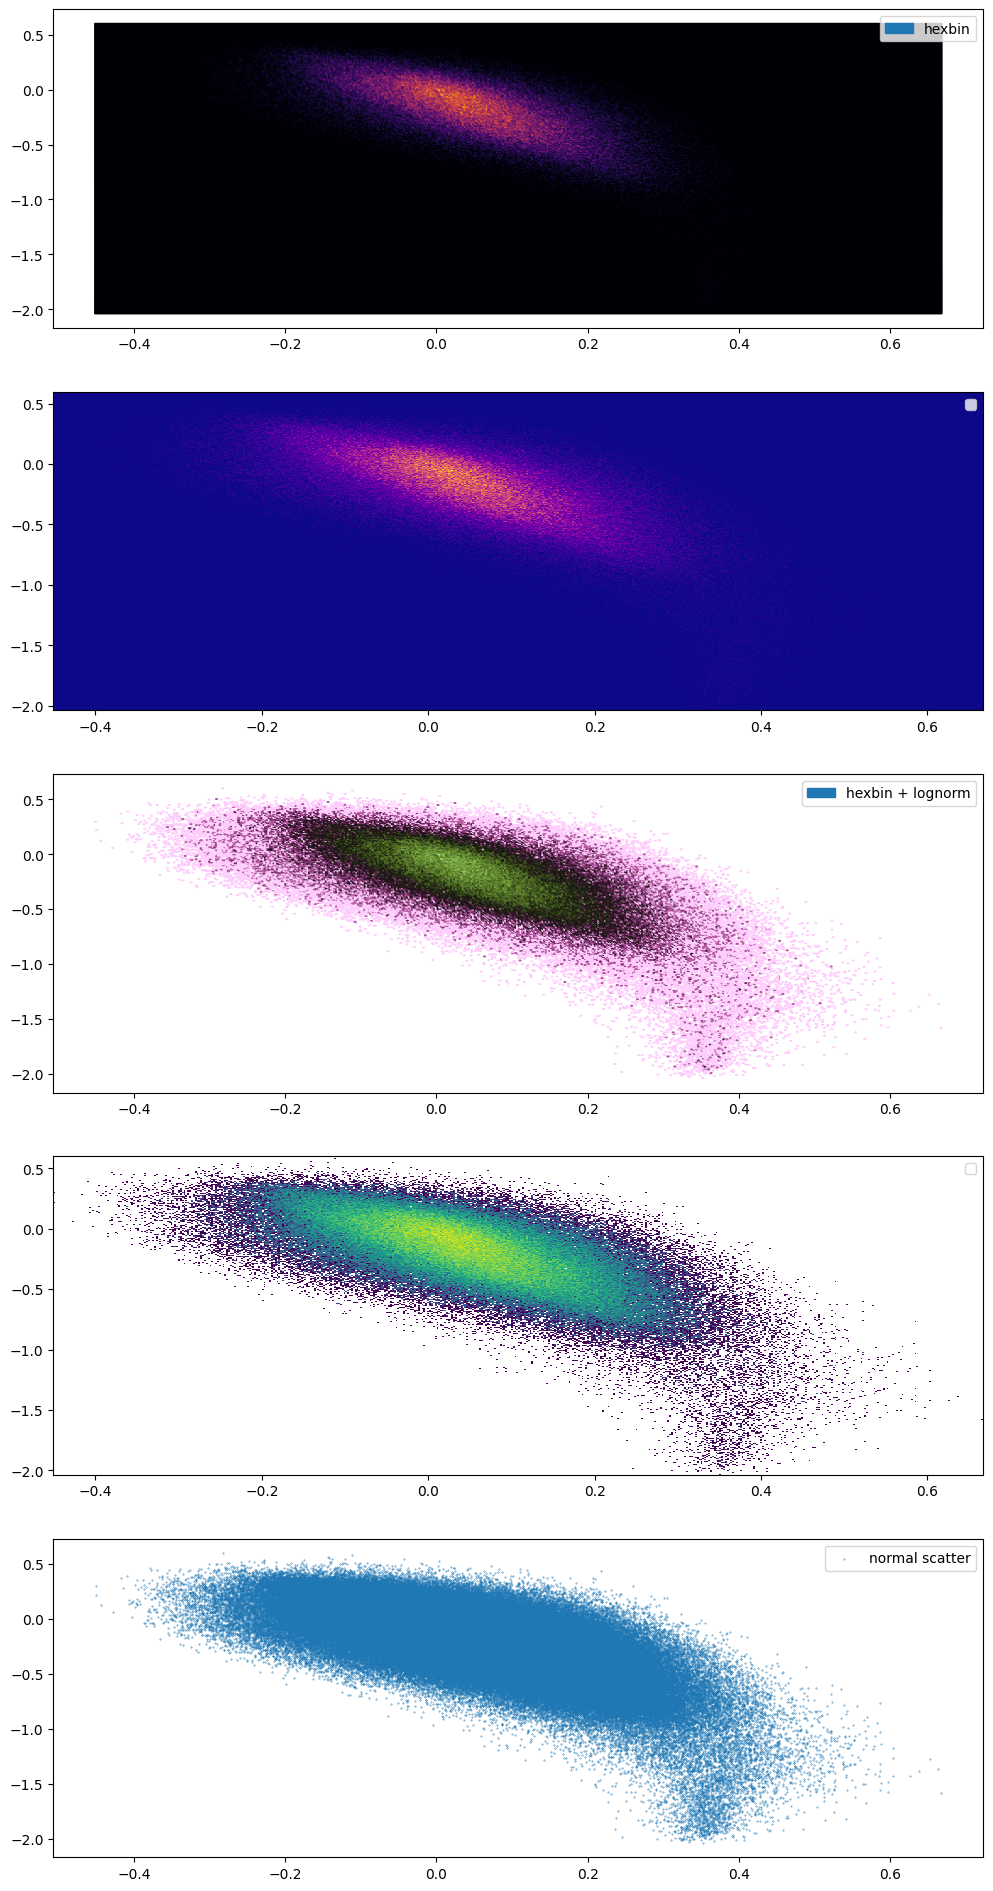

In [10]:
fig, ax = plt.subplots(5, 1, sharex=False, sharey=False, figsize=(12, 24)) # (rows, colums, share y axis and/or share x axis)


ax[0].hexbin(flagged['CaFe'], flagged['FeH'], gridsize=500, cmap='inferno', label = "hexbin") 
ax[1].hist2d(flagged['CaFe'], flagged['FeH'], bins=500, cmap='plasma', label = "hist2d" ) 
ax[2].hexbin(flagged['CaFe'], flagged['FeH'], gridsize=500, norm=LogNorm(), cmap='vanimo', label = "hexbin + lognorm" ) 
ax[3].hist2d(flagged['CaFe'], flagged['FeH'], bins=500, norm=LogNorm(), cmap='viridis', label = "hist2d + lognorm" ) 
ax[4].scatter(flagged['CaFe'], flagged['FeH'], s=0.1, label = "normal scatter") 

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()
ax[4].legend();

In [ ]:
plt.figure(figsize=(10, 8))
sns.kdeplot(
    x=flagged['CaFe'],
    y=flagged['FeH'],
    levels=8,
    fill=False,
    cmap='viridis',
    thresh=0.05,
    linewidths=1.5,
    bw_method='scott'
)
plt.scatter(flagged['CaFe'], flagged['FeH'], s=1, c='gray', alpha=0.25)
plt.xlabel('[Ca/Fe]')
plt.ylabel('[Fe/H]')
plt.title('Seaborn contour plot of [Ca/Fe] vs [Fe/H]')
plt.grid(alpha=0.3)
plt.show()

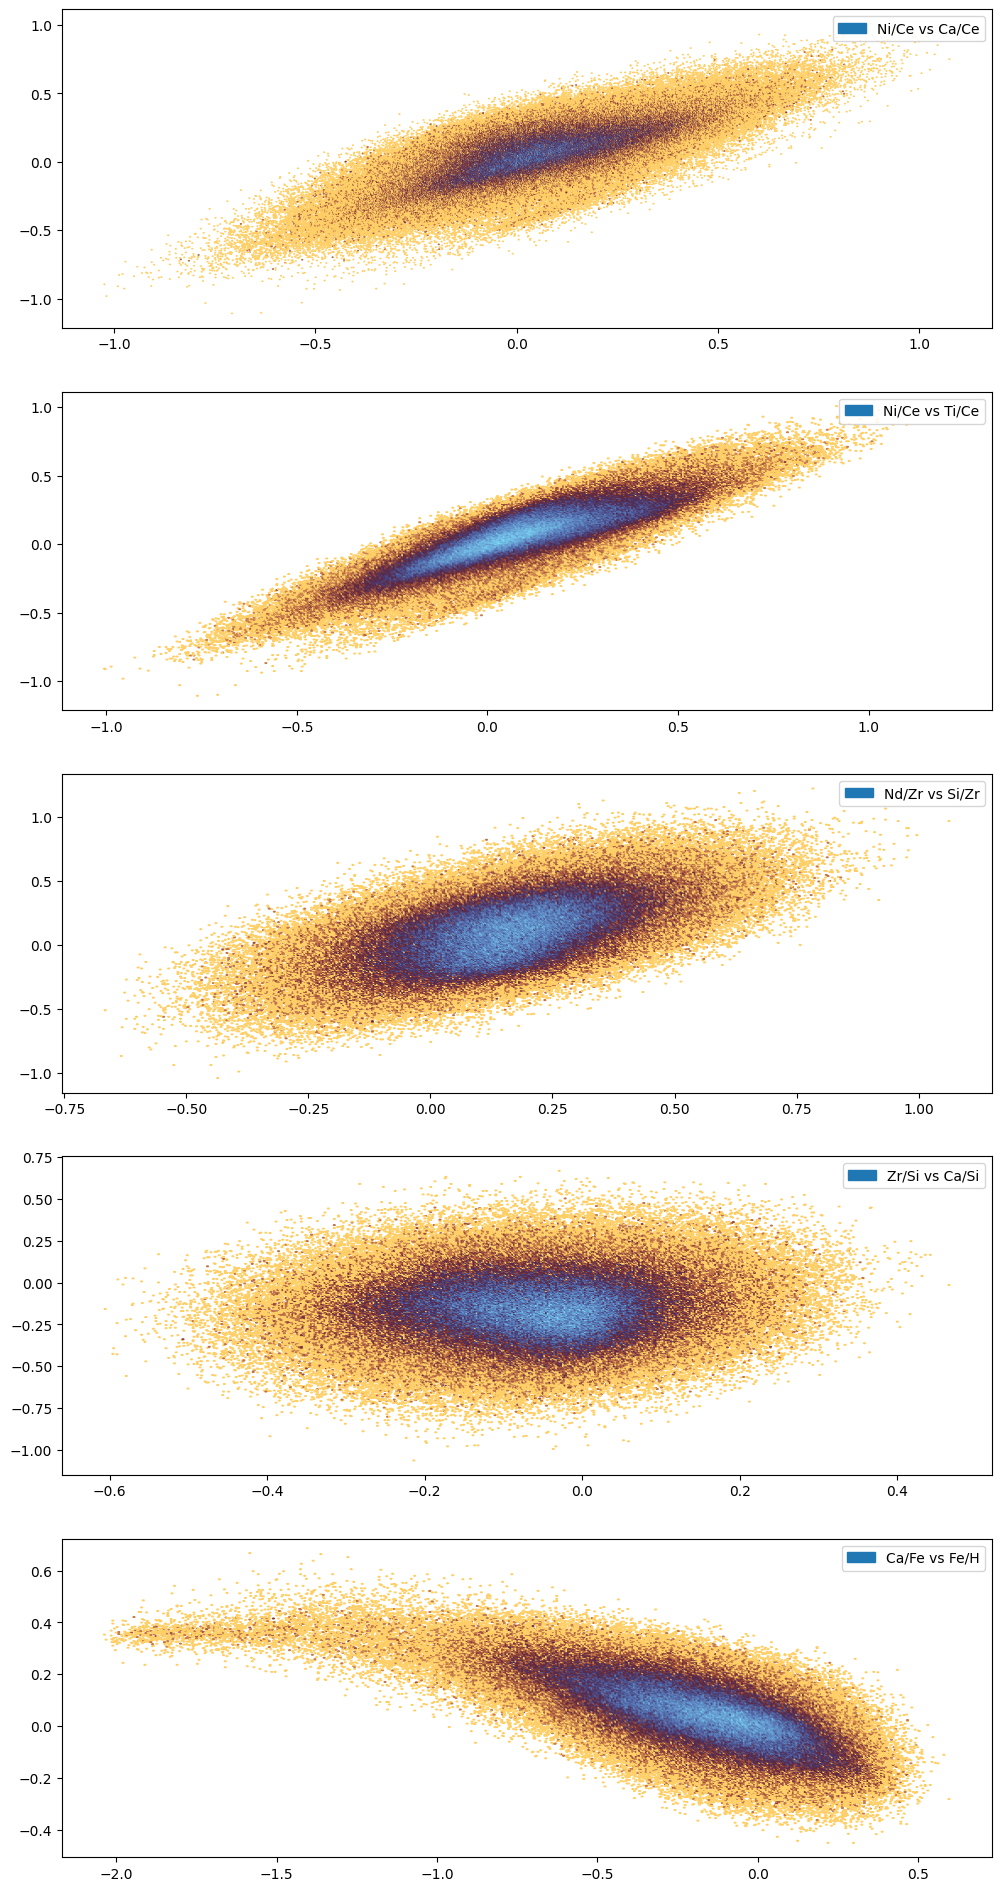

In [11]:
fig, ax = plt.subplots(5, 1, sharex=False, sharey=False, figsize=(12, 24)) # (rows, colums, share y axis and/or share x axis)

ax[0].hexbin(flagged['CaFe'] - flagged['CeFe'], flagged['NiFe'] - flagged['CeFe'], gridsize=1000, norm=LogNorm(), cmap='managua', label = "Ni/Ce vs Ca/Ce" ) 
ax[1].hexbin(flagged['TiFe'] - flagged['CeFe'], flagged['NiFe'] - flagged['CeFe'], gridsize=500, norm=LogNorm(), cmap='managua', label = "Ni/Ce vs Ti/Ce" )
ax[2].hexbin(flagged['SiFe'] - flagged['ZrFe'], flagged['NdFe'] - flagged['ZrFe'], gridsize=500, norm=LogNorm(), cmap='managua', label = "Nd/Zr vs Si/Zr" )
ax[3].hexbin(flagged['CaFe'] - flagged['SiFe'], flagged['ZrFe'] - flagged['SiFe'], gridsize=500, norm=LogNorm(), cmap='managua', label = "Zr/Si vs Ca/Si" )
ax[4].hexbin(flagged['FeH'] , flagged['CaFe'], gridsize=500, norm=LogNorm(), cmap='managua', label = "Ca/Fe vs Fe/H" )

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()
ax[4].legend();

Text(0.5, 0, '[Ca/Ce]')

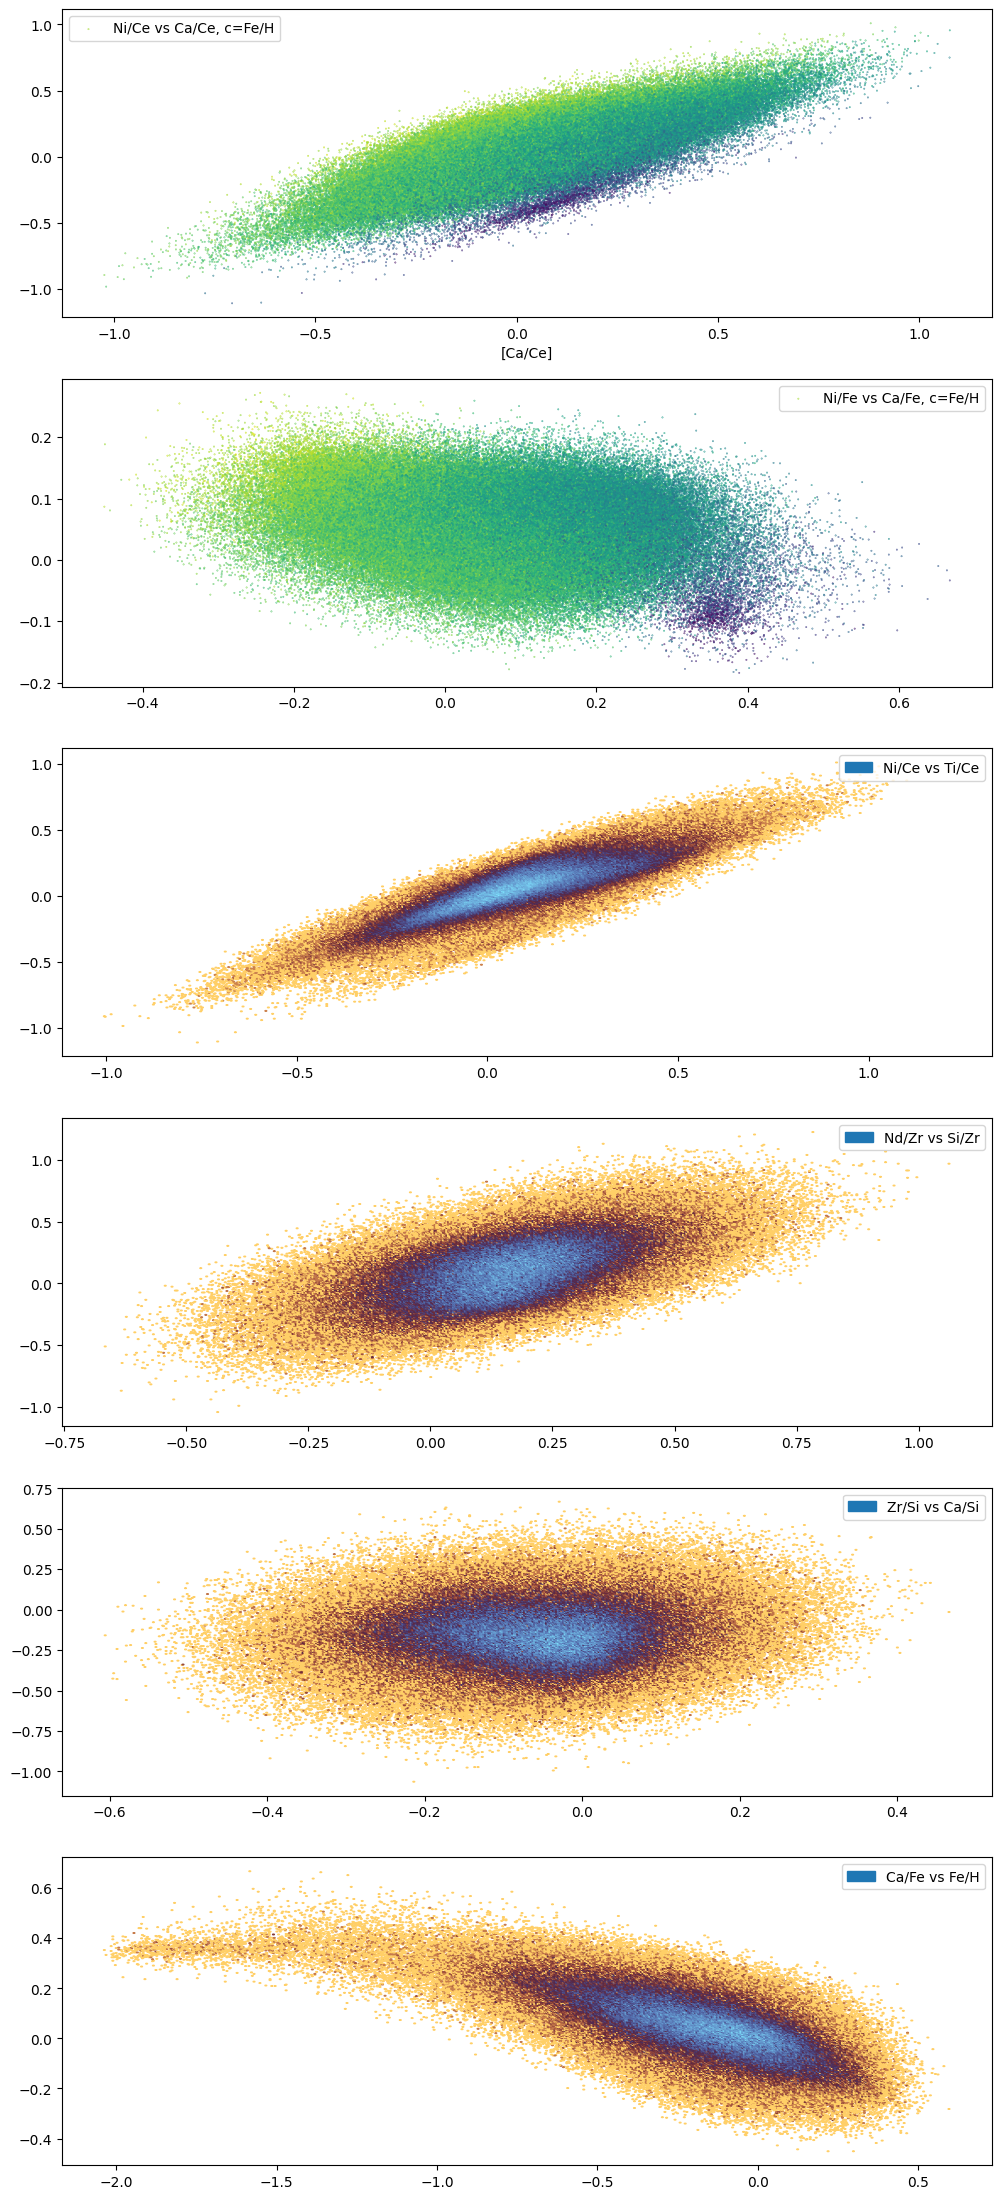

In [12]:
fig, ax = plt.subplots(6, 1, sharex=False, sharey=False, figsize=(12, 28)) # (rows, colums, share y axis and/or share x axis)

ax[0].scatter(flagged['CaFe'] - flagged['CeFe'], flagged['NiFe'] - flagged['CeFe'], c = flagged['FeH'], s = 0.1, label = "Ni/Ce vs Ca/Ce, c=Fe/H" )
ax[1].scatter(flagged['CaFe'], flagged['NiFe'], c = flagged['FeH'], s = 0.1, label = "Ni/Fe vs Ca/Fe, c=Fe/H" ) 
ax[2].hexbin(flagged['TiFe'] - flagged['CeFe'], flagged['NiFe'] - flagged['CeFe'], gridsize=500, norm=LogNorm(), cmap='managua', label = "Ni/Ce vs Ti/Ce" )
ax[3].hexbin(flagged['SiFe'] - flagged['ZrFe'], flagged['NdFe'] - flagged['ZrFe'], gridsize=500, norm=LogNorm(), cmap='managua', label = "Nd/Zr vs Si/Zr" )
ax[4].hexbin(flagged['CaFe'] - flagged['SiFe'], flagged['ZrFe'] - flagged['SiFe'], gridsize=500, norm=LogNorm(), cmap='managua', label = "Zr/Si vs Ca/Si" )
ax[5].hexbin(flagged['FeH'] , flagged['CaFe'], gridsize=500, norm=LogNorm(), cmap='managua', label = "Ca/Fe vs Fe/H" )

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()
ax[4].legend()
ax[5].legend()

ax[0].set_xlabel("[Ca/Ce]")

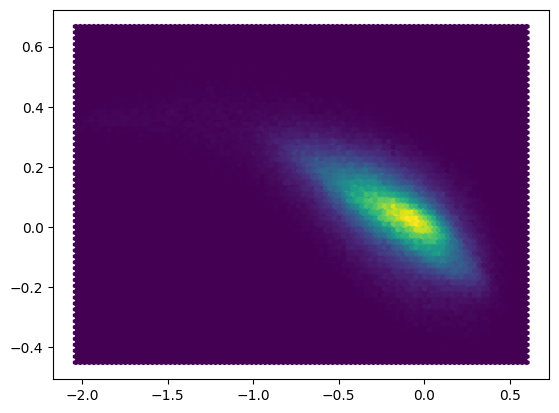

In [13]:
plt.hexbin(flagged['FeH'], flagged['CaFe'], ) #, gridsize=500, norm=LogNorm(), cmap='managua',)

In [14]:
print(MWPotential2014)

[<galpy.potential.PowerSphericalPotentialwCutoff.PowerSphericalPotentialwCutoff object at 0x784a41676e40>, <galpy.potential.MiyamotoNagaiPotential.MiyamotoNagaiPotential object at 0x784a4164f4d0>, <galpy.potential.TwoPowerSphericalPotential.NFWPotential object at 0x784a4164fd90>]


In [15]:
R = 0.3
v_circ = vcirc(MWPotential2014, R)

print(v_circ)

0.9063374870690126


In [16]:
R = 0.1  # galpy units (~8 kpc)
z = 0.0

FR = evaluateRforces(MWPotential2014, R, z)
print(FR)

-3.433042436197158


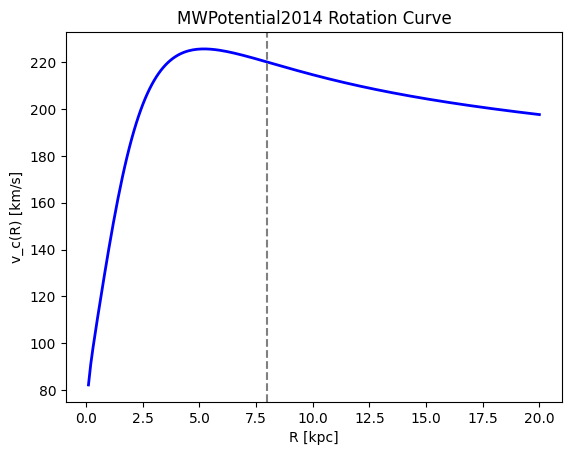

In [17]:
Rs = np.linspace(0.1, 20.0, 200)  # kpc
vcs = vcirc(MWPotential2014, Rs/8.0) * 220.0  # km/s
plt.plot(Rs, vcs, 'b-', lw=2)
plt.axvline(8.0, ls='--', color='gray')
plt.xlabel('R [kpc]')
plt.ylabel('v_c(R) [km/s]')
plt.title('MWPotential2014 Rotation Curve')
plt.show()

<Figure size 640x480 with 0 Axes>

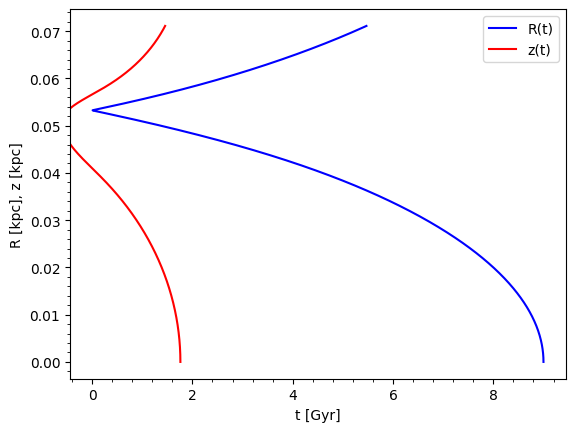

In [18]:
o = Orbit(vxvv=[9.0/8.0, 0.0, 0.0, 0.22, 0.0, 0.0]) # yea i dont get this part t all. I do understand what the plot above is.
ts = np.linspace(0.0, 2.0, 1001)
o.integrate(ts, MWPotential2014)
plt.figure()
o.plot(d1='R', d2='t', ro=8., vo=220., color='b', overplot=False)
o.plot(d1='z', d2='t', ro=8., vo=220., color='r', overplot=True)
plt.legend(['R(t)', 'z(t)'])
plt.xlabel('t [Gyr]')
plt.ylabel('R [kpc], z [kpc]')
plt.show()

In [19]:
C = np.array([0,1,2,3,4,5,6,7])

A = C**3

B = C**2



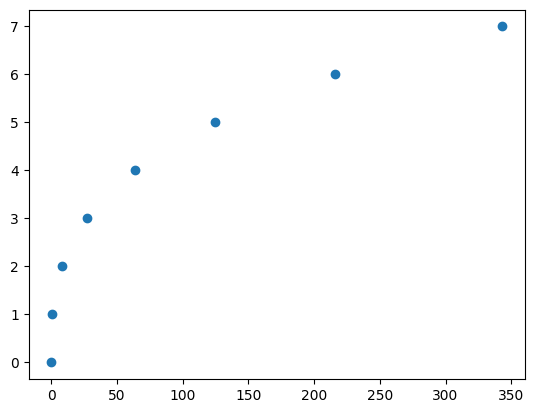

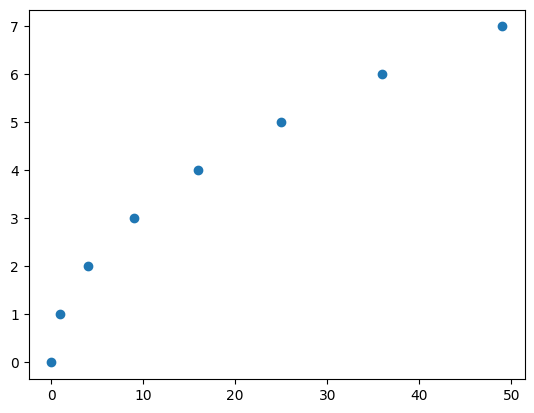

In [20]:
for i in [A,B]:

    plt.figure()
    plt.scatter(i,C)

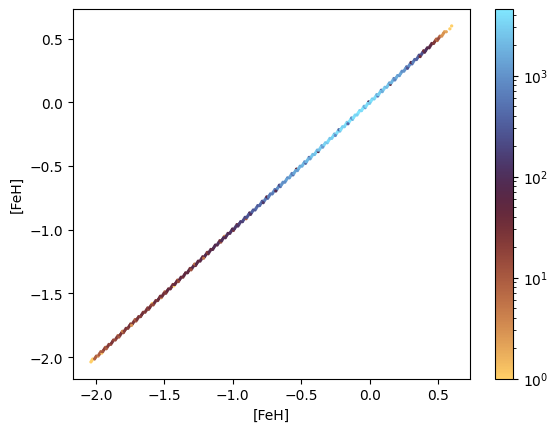

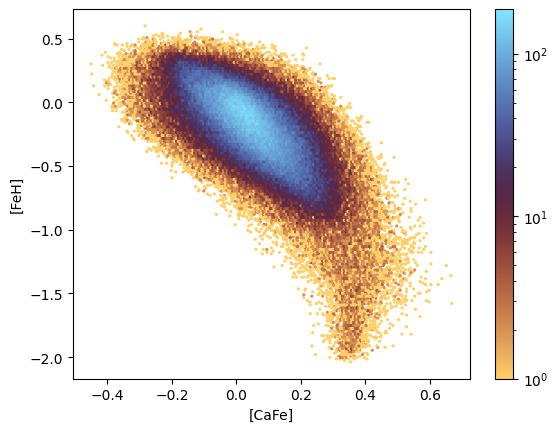

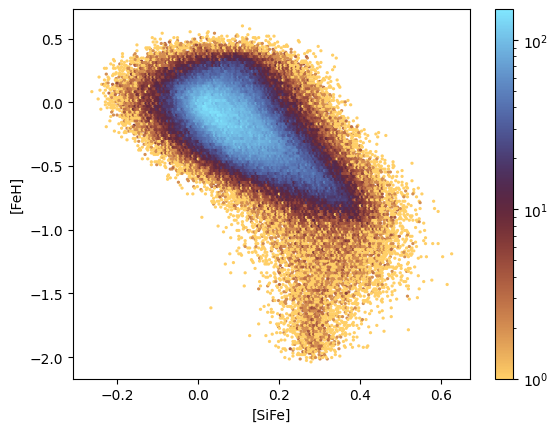

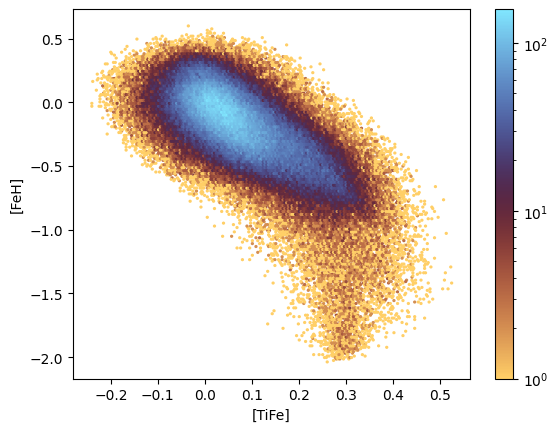

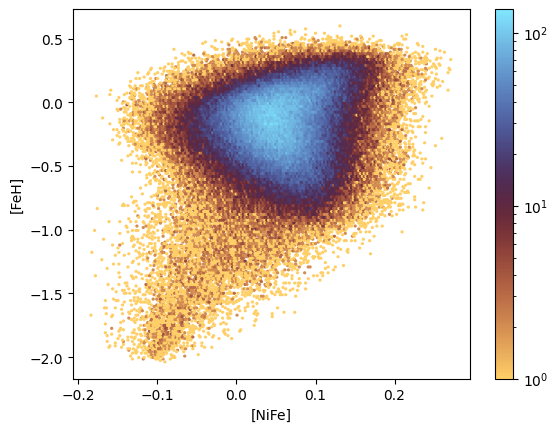

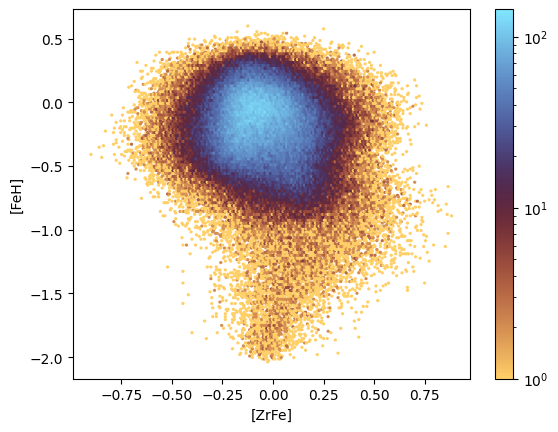

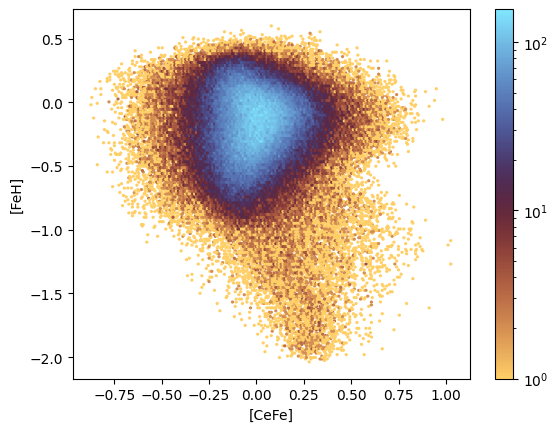

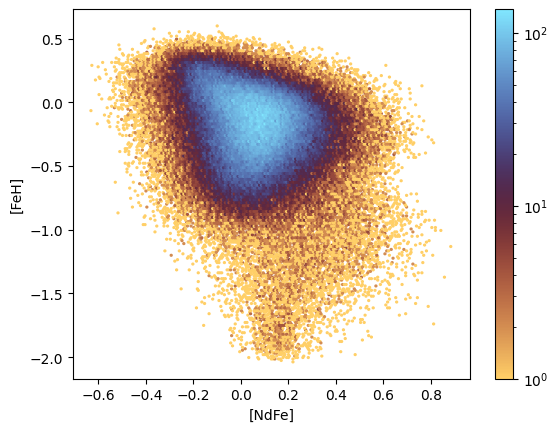

In [21]:
for i in chem_list:
    plt.figure()
    plt.hexbin(flagged[i],flagged["FeH"],gridsize=200, norm=LogNorm(), cmap='managua',)
    plt.xlabel(F"[{i}]")
    plt.ylabel("[FeH]")
    plt.colorbar()

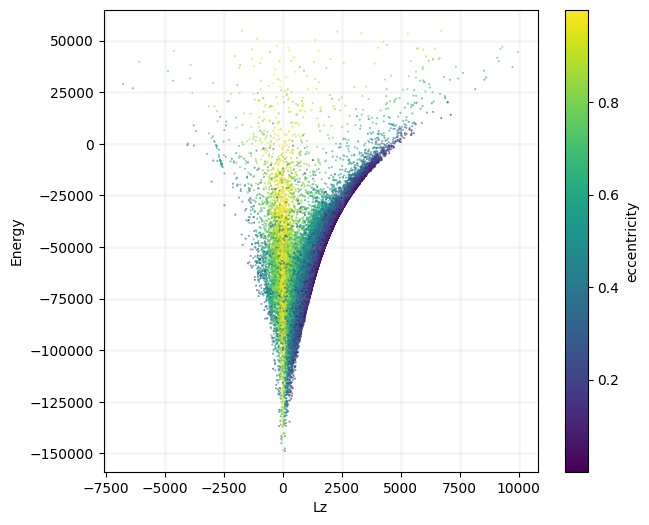

In [29]:
plt.figure( figsize = (7,6))

plt.scatter(dogofull["Lz"], dogofull['Energy'], c = dogofull['eccentricity'], s= 0.1)

plt.xlabel("Lz")
plt.ylabel('Energy')
plt.colorbar( label ="eccentricity")
plt.grid( alpha = 0.1, linewidth = 2 )

<Figure size 900x900 with 0 Axes>

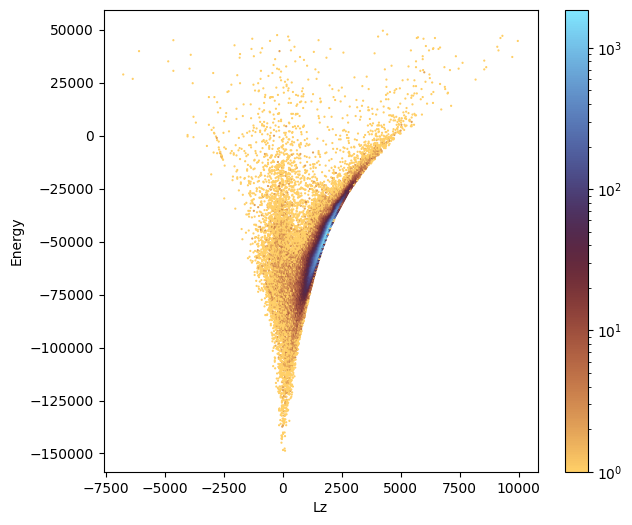

In [ ]:
# plt.figure( figsize = (9,9))

# dogo2 = dogofull[(dogofull['Energy'] < 50000) & (dogofull['Lz'] < 10000) & (dogofull['Lz']> -7500)]
# # dogo2 = dogo2[-7500 < dogo2['Lz'] < 10000]

# plt.figure( figsize = (7,6))

# plt.hexbin(dogo2["Lz"], dogo2['Energy'], gridsize=500, norm=LogNorm(), cmap='managua',)

# plt.xlabel("Lz")
# plt.ylabel('Energy')
# plt.grid( alpha = 0.1, linewidth = 2 )
# plt.colorbar()

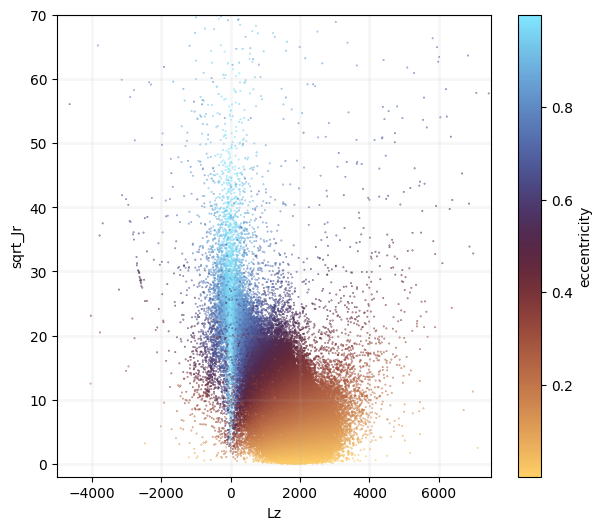

In [23]:
plt.figure( figsize = (7,6))

plt.scatter(dogofull["Lz"], dogofull['sqrt_Jr'], c = dogofull['eccentricity'], s= 0.1, cmap = "managua")

plt.xlabel("Lz")
plt.ylabel('sqrt_Jr')
plt.colorbar( label ="eccentricity")
plt.grid( alpha = 0.1, linewidth = 2 )

plt.ylim(-2, 70)
plt.xlim(-5000, 7500);

Text(0, 0.5, '[Nd/Zr]')

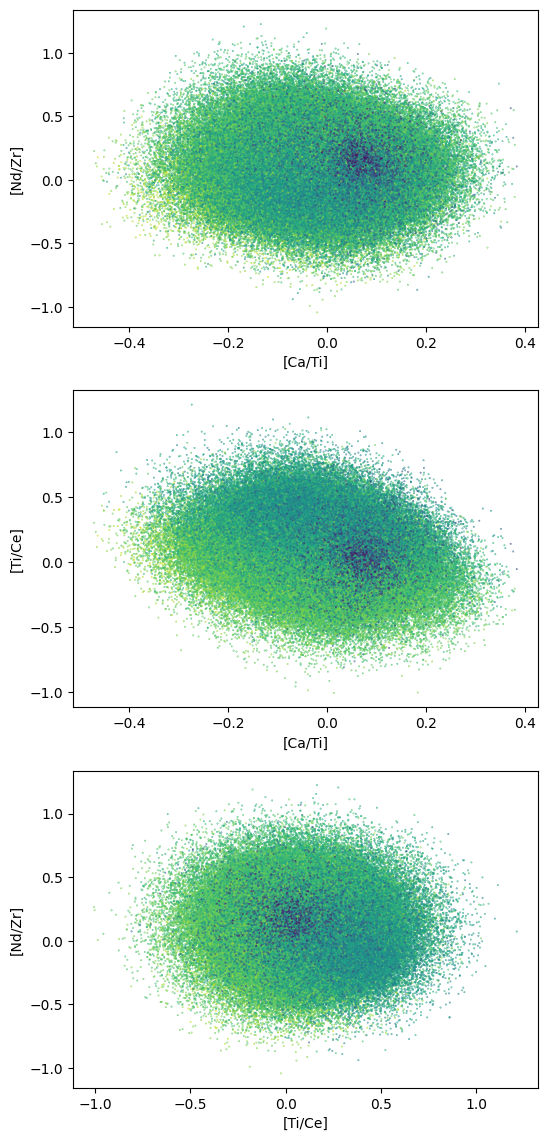

In [24]:
fig, ax = plt.subplots(3, 1, sharex=False, sharey=False, figsize=(6, 14)) # (rows, colums, share y axis and/or share x axis)

ax[0].scatter(flagged['CaFe'] - flagged['TiFe'], flagged['NdFe'] - flagged['ZrFe'], c = flagged['FeH'], s = 0.1,)
ax[1].scatter(flagged['CaFe'] - flagged['TiFe'], flagged['TiFe'] - flagged['CeFe'], c = flagged['FeH'], s = 0.1,)
ax[2].scatter(flagged['TiFe'] - flagged['CeFe'], flagged['NdFe'] - flagged['ZrFe'], c = flagged['FeH'], s = 0.1,)

ax[0].set_xlabel("[Ca/Ti]")
ax[0].set_ylabel("[Nd/Zr]")

ax[1].set_xlabel("[Ca/Ti]")
ax[1].set_ylabel("[Ti/Ce]")

ax[2].set_xlabel("[Ti/Ce]")
ax[2].set_ylabel("[Nd/Zr]")

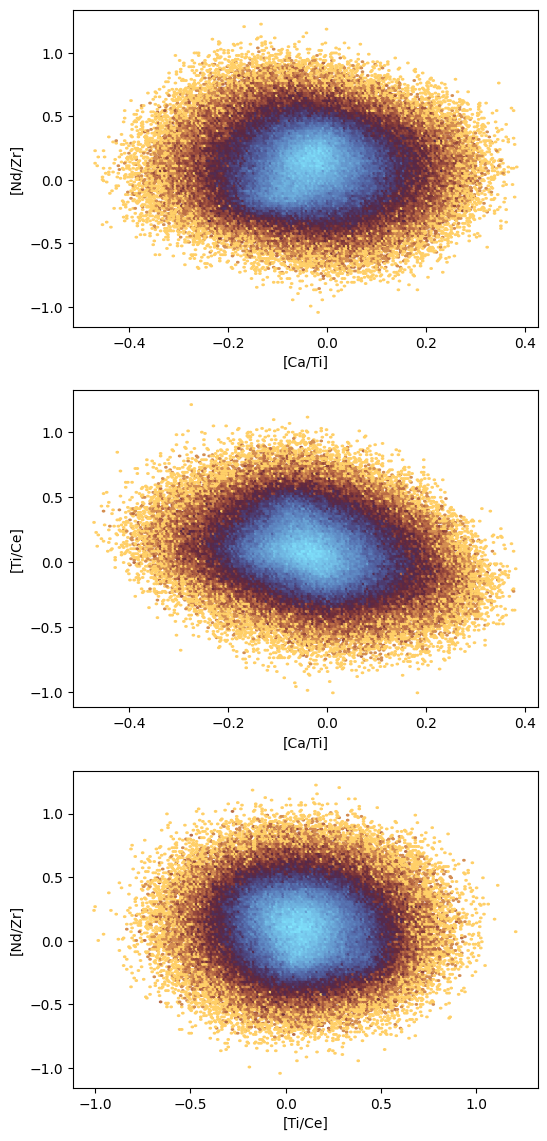

In [25]:
fig, ax = plt.subplots(3, 1, sharex=False, sharey=False, figsize=(6, 14)) # (rows, colums, share y axis and/or share x axis)

ax[0].hexbin(flagged['CaFe'] - flagged['TiFe'], flagged['NdFe'] - flagged['ZrFe'], gridsize=200, norm=LogNorm(), cmap='managua',)
ax[1].hexbin(flagged['CaFe'] - flagged['TiFe'], flagged['TiFe'] - flagged['CeFe'], gridsize=200, norm=LogNorm(), cmap='managua',)
ax[2].hexbin(flagged['TiFe'] - flagged['CeFe'], flagged['NdFe'] - flagged['ZrFe'], gridsize=200, norm=LogNorm(), cmap='managua',)

ax[0].set_xlabel("[Ca/Ti]")
ax[0].set_ylabel("[Nd/Zr]")

ax[1].set_xlabel("[Ca/Ti]")
ax[1].set_ylabel("[Ti/Ce]")

ax[2].set_xlabel("[Ti/Ce]")
ax[2].set_ylabel("[Nd/Zr]");

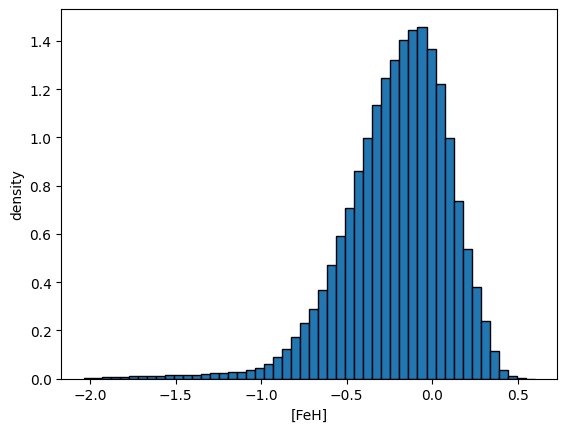

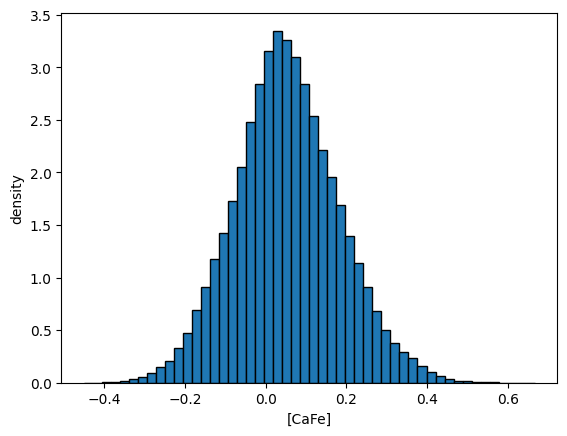

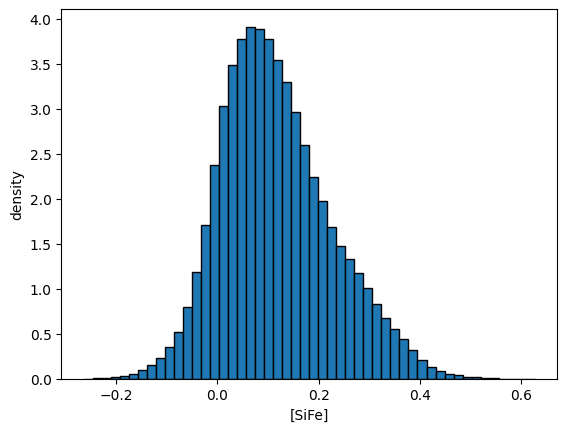

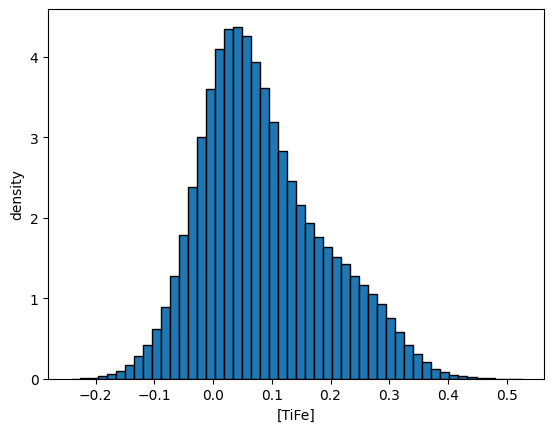

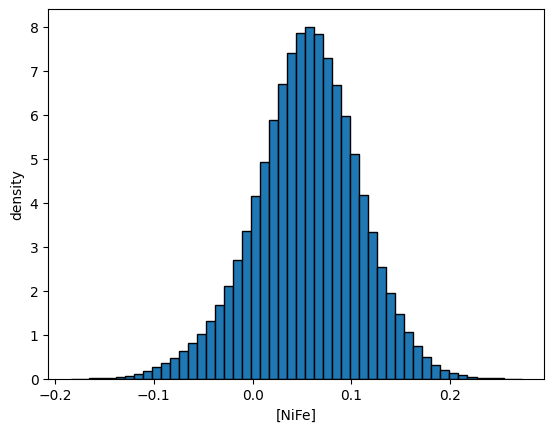

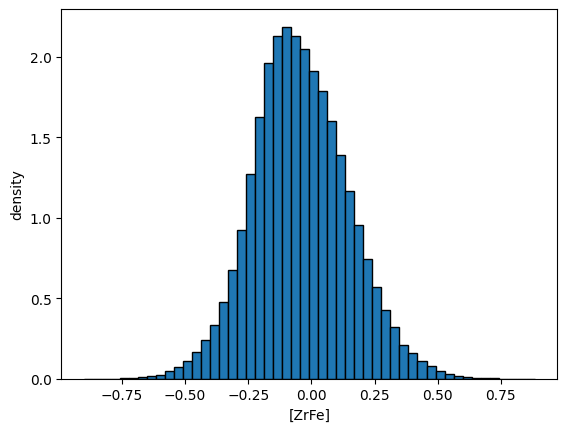

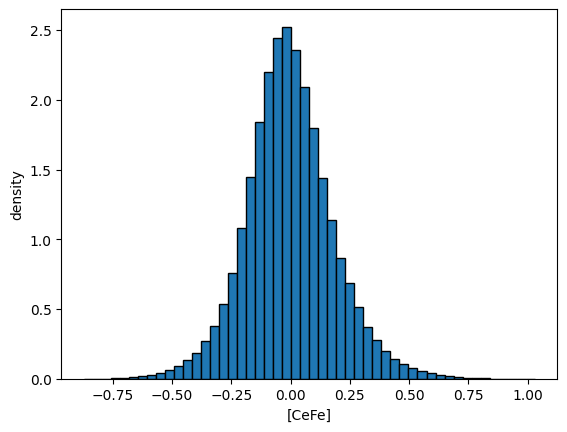

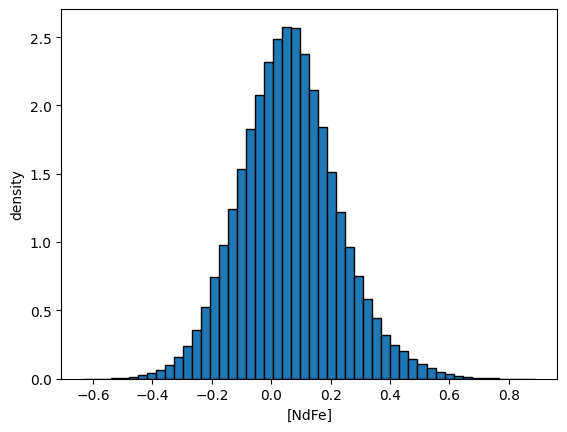

In [26]:
for i in chem_list:
    plt.figure()
    plt.hist(flagged[i],bins=50,edgecolor = "black", density= True)
    plt.xlabel(F"[{i}]")
    plt.ylabel("density")
    # plt.colorbar()

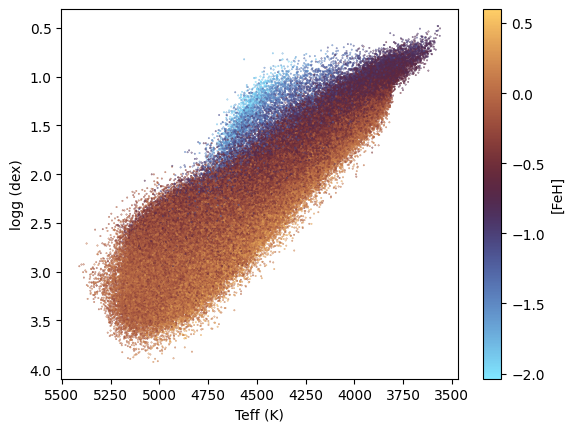

In [27]:
plt.scatter(flagged["Teff"], flagged["logg"], c = flagged["FeH"], s = 0.1, cmap = "managua_r") #, vmin = -3, vmax = 2 )

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.xlabel("Teff (K)")
plt.ylabel("logg (dex)")
plt.colorbar( label = "[FeH]");


